**Date**:


**DTSC-610**

**Author**: Milon Velarde, Martin A.

**NYIT ID**: 1091404

**Project Final Report**

**1) Introduction:**

This report will explore 2 data sets from the United Nations High Commissioner for Refugees’s (UNHCR) Refugee Population Statistics Database.
For each data set, a description and visualizations are provided.

**2) Getting Ready to Explore the Data**:

In [ ]:
# Upload files
from google.colab import files
uploaded = files.upload()
uploaded = files.upload()

In [ ]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
# Save paths to variables
# Population Data Set
population_path = "/content/demographics[1].csv"
# Decisions Data Set
decisions_path = "/content/asylum-decisions[1].csv"

In [ ]:
# Population DataFrame
population_df = pd.read_csv(population_path, skiprows=14) # Skip to row 15
# Decisions DataFrame
decisions_df = pd.read_csv(decisions_path)

In [ ]:
population_df.head()

,Year,Country of origin,Country of origin (ISO),Country of asylum,Country of asylum (ISO),Female 0 - 4,Female 5 - 11,Female 12 - 17,Female 18 - 59,Female 60,Female other,Female total,Male 0 - 4,Male 5 - 11,Male 12 - 17,Male 18 - 59,Male 60,Male other,Male total,Total
0,2001,North Macedonia,MKD,Albania,ALB,0,0,0,8,0,0,8,0,0,0,21,0,0,21,29
1,2001,Serbia and Kosovo: S/RES/1244 (1999),SRB,Albania,ALB,0,0,0,0,0,0,0,0,0,0,5,0,0,5,5
2,2001,Türkiye,TUR,Albania,ALB,0,0,0,0,0,0,0,0,0,0,37,0,0,37,37
3,2001,Chad,TCD,Algeria,DZA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5
4,2001,Congo,COG,Algeria,DZA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,27


In [ ]:
decisions_df.head()

,Year,Country of origin,Country of origin (ISO),Country of asylum,Country of asylum (ISO),Authority,Stage of procedure,Cases / Persons,Recognized decisions,Complementary protection,Rejected decisions,Otherwise closed,Total decisions
0,2000,Afghanistan,AFG,Australia,AUS,G,AR,C,38,0,25,0,63
1,2000,Albania,ALB,Australia,AUS,G,AR,C,5,0,24,0,29
2,2000,Algeria,DZA,Australia,AUS,G,AR,C,5,0,17,0,22
3,2000,Egypt,EGY,Australia,AUS,G,AR,C,21,0,50,5,76
4,2000,Armenia,ARM,Australia,AUS,G,AR,C,0,0,5,0,5


In [ ]:
population_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69934 entries, 0 to 69933
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Year                     69934 non-null  int64 
 1   Country of origin        69934 non-null  object
 2   Country of origin (ISO)  69934 non-null  object
 3   Country of asylum        69934 non-null  object
 4   Country of asylum (ISO)  69934 non-null  object
 5   Female 0 - 4             69934 non-null  int64 
 6   Female 5 - 11            69934 non-null  int64 
 7   Female 12 - 17           69934 non-null  int64 
 8   Female 18 - 59           69934 non-null  int64 
 9   Female 60                69934 non-null  int64 
 10  Female other             69934 non-null  int64 
 11  Female total             69934 non-null  int64 
 12  Male 0 - 4               69934 non-null  int64 
 13  Male 5 - 11              69934 non-null  int64 
 14  Male 12 - 17             69934 non-nul

In [ ]:
decisions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103034 entries, 0 to 103033
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   Year                      103034 non-null  int64 
 1   Country of origin         103034 non-null  object
 2   Country of origin (ISO)   103034 non-null  object
 3   Country of asylum         103034 non-null  object
 4   Country of asylum (ISO)   103034 non-null  object
 5   Authority                 103034 non-null  object
 6   Stage of procedure        100897 non-null  object
 7   Cases / Persons           103034 non-null  object
 8   Recognized decisions      103034 non-null  int64 
 9   Complementary protection  103034 non-null  int64 
 10  Rejected decisions        103034 non-null  int64 
 11  Otherwise closed          103034 non-null  int64 
 12  Total decisions           103034 non-null  int64 
dtypes: int64(6), object(7)
memory usage: 10.2+ MB


In [ ]:
population_df.describe().round(2)

,Year,Female 0 - 4,Female 5 - 11,Female 12 - 17,Female 18 - 59,Female 60,Female other,Female total,Male 0 - 4,Male 5 - 11,Male 12 - 17,Male 18 - 59,Male 60,Male other,Male total,Total
count,69934.00,69934.00,69934.00,69934.00,69934.00,69934.00,69934.00,69934.00,69934.00,69934.00,69934.00,69934.00,69934.00,69934.00,69934.00,69934.00
mean,2013.91,12.00,16.96,12.19,69.92,3.35,15.67,130.09,12.52,18.29,15.78,121.64,3.19,34.63,206.04,773.74
std,6.41,153.18,238.69,158.50,1194.44,89.73,507.63,1761.95,160.58,257.41,217.04,1740.24,73.19,1149.86,2540.31,8680.96
min,2001.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5.00
25%,2009.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,8.00
50%,2015.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,24.00
75%,2019.00,0.00,0.00,0.00,0.00,0.00,0.00,8.00,0.00,0.00,0.00,8.00,0.00,0.00,15.00,131.00
max,2023.00,10093.00,18403.00,11826.00,199112.00,13828.00,107416.00,232170.00,10838.00,19456.00,21609.00,267109.00,10869.00,250640.00,299652.00,940668.00


In [ ]:
decisions_df.describe().round(2)

,Year,Recognized decisions,Complementary protection,Rejected decisions,Otherwise closed,Total decisions
count,103034.00,103034.00,103034.00,103034.00,103034.00,103034.00
mean,2012.61,66.57,27.88,110.78,90.60,295.99
std,6.84,953.36,1097.08,811.18,2046.83,2941.42
min,2000.00,0.00,0.00,0.00,0.00,0.00
25%,2007.00,0.00,0.00,0.00,0.00,5.00
50%,2013.00,0.00,0.00,5.00,5.00,19.00
75%,2018.00,10.00,0.00,33.00,16.00,92.00
max,2023.00,164926.00,248201.00,147063.00,543233.00,543233.00


In [ ]:
# Create a Pivot Table to sum total asylum seeker population per country of origin
population_pivot = population_df.pivot_table(index='Country of origin', values='Total', aggfunc='sum')
population_pivot
# Create a Pivot Table to sum total decisions over time
decisions_pivot = decisions_df.pivot_table(index='Country of origin', values='Total decisions', aggfunc='sum')
decisions_pivot
# Combime pivot tables
origin_pivot = pd.concat([population_pivot, decisions_pivot], axis=1)
origin_pivot = origin_pivot.dropna()

In [ ]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(origin_pivot)
# X_scaled

In [ ]:
# Calculate WCSS for different numbers of clusters
wcss_values = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss_values.append(kmeans.inertia_)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

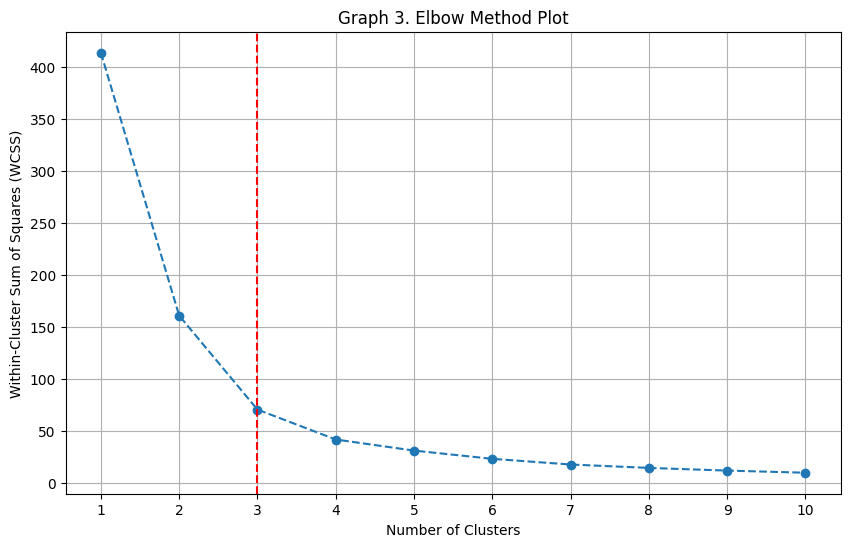

In [ ]:
# Plot the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss_values, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Graph 3. Elbow Method Plot')
plt.xticks(range(1, 11))
plt.grid(True)
# add vertical line where number of clusters = 3
plt.axvline(x=3, color='red', linestyle='--')
plt.show()

In [ ]:
# Perform K-means clustering
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, max_iter=300, n_init=10)
cluster_labels = kmeans.fit_predict(origin_pivot)



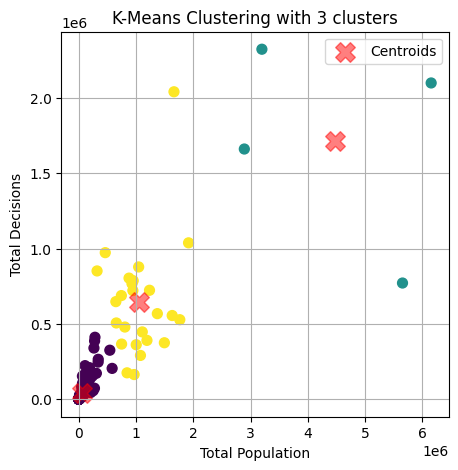

In [ ]:
# Visualizing the clusters

plt.scatter(origin_pivot.iloc[:, 0], origin_pivot.iloc[:, 1], c=cluster_labels, s=50, cmap='viridis') # Use .iloc to index the DataFrame
# Plotting centroids of the clusters
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', marker='X', label='Centroids', alpha=0.5)

plt.xlabel('Total Population')
plt.ylabel('Total Decisions')
plt.title('K-Means Clustering with {} clusters'.format(3))
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Table: cluster centers
centers_df = pd.DataFrame(kmeans.cluster_centers_, columns=['Total', 'Total decisions'])
centers_df.index = ['Cluster 0', 'Cluster 1', 'Cluster 2']
centers_df

,Total,Total decisions
Cluster 0,5.532512e+04,4.227373e+04
Cluster 1,4.475056e+06,1.713038e+06
Cluster 2,1.054495e+06,6.448116e+05


In [ ]:
# Perform K-means clustering
origin_pivot = origin_pivot[['Total', 'Total decisions']].dropna() # Drop rows with NaN values
origin_pivot = origin_pivot.round(2)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(origin_pivot)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


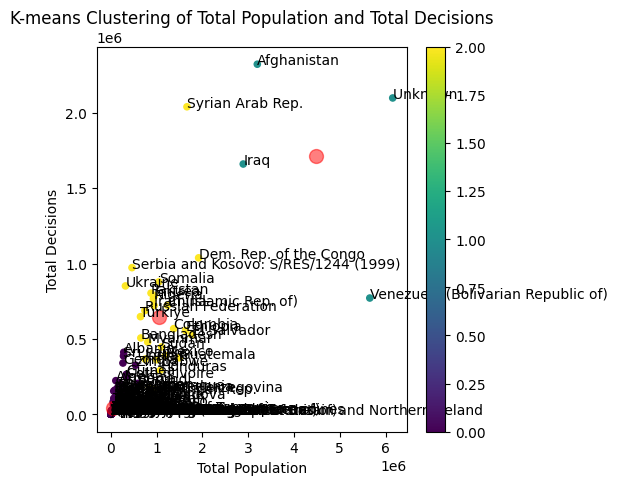

In [ ]:
# Plot the clusters
origin_pivot.plot(kind='scatter', x='Total', y='Total decisions', c=clusters, colormap='viridis')
plt.title('K-means Clustering of Total Population and Total Decisions')
plt.xlabel('Total Population')
plt.ylabel('Total Decisions')
# add year labels
for year in origin_pivot.index:
    plt.annotate(str(year), (origin_pivot.loc[year, 'Total'], origin_pivot.loc[year, 'Total decisions']))

# show centers
centers = kmeans.cluster_centers_
centers = centers.round(2)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=100, alpha=0.5)

In [ ]:
# Table: Cluster Centers
centers_df = pd.DataFrame(centers, columns=['Total', 'Total decisions'])
centers_df.index = ['Cluster 0', 'Cluster 1', 'Cluster 2']
centers_df= centers_df.round(2)
centers_df


,Total,Total decisions
Cluster 0,1165456.57,869346.71
Cluster 1,6150409.00,2278070.50
Cluster 2,3641902.71,1811412.14


In [ ]:
# Table: Number of Points in Each Cluster
cluster_counts = pd.Series(clusters).value_counts()
cluster_counts.index = ['Cluster 0', 'Cluster 1', 'Cluster 2']
cluster_counts

Cluster 0    178
Cluster 1     25
Cluster 2      4
Name: count, dtype: int64

In [ ]:
# Elbow Method Plot


In [ ]:
# Create a Pivot Table to sum total asylum seeker population over time
population_pivot = population_df.pivot_table(index='Year', values='Total', aggfunc='sum')
population_pivot
# Create a Pivot Table to sum total decisions over time
decisions_pivot = decisions_df.pivot_table(index='Year', values='Total decisions', aggfunc='sum')
decisions_pivot
# Combime pivot tables
USA_pivot = pd.concat([population_pivot, decisions_pivot], axis=1)
USA_pivot

,Total,Total decisions
Year,,
2001,943383.0,946486
2002,1093121.0,1010251
2003,995567.0,1002084
2004,884285.0,891175
2005,801119.0,829228
2006,740253.0,692537
2007,1151867.0,644001
2008,1647862.0,706269
2009,1976060.0,762119


In [ ]:
# Perform K-means clustering
X = USA_pivot[['Total', 'Total decisions']].dropna() # Drop rows with NaN values
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)
# Create a new DataFrame to store cluster labels and align with the original DataFrame
cluster_df = pd.DataFrame(clusters, columns=['Cluster'], index=X.index)
# Join cluster labels with the original DataFrame based on the index
USA_pivot = USA_pivot.join(cluster_df)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


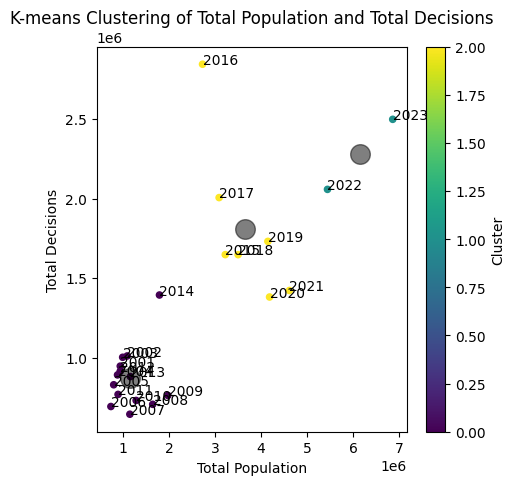

In [ ]:
# Plot the clusters
USA_pivot.plot(kind='scatter', x='Total', y='Total decisions', c='Cluster', colormap='viridis')
plt.title('K-means Clustering of Total Population and Total Decisions')
plt.xlabel('Total Population')
plt.ylabel('Total Decisions')
# add year labels
for year in USA_pivot.index:
    plt.annotate(str(year), (USA_pivot.loc[year, 'Total'], USA_pivot.loc[year, 'Total decisions']))

# show centers
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)

In [ ]:
# Extract USA data from population_df
USA_population_df = population_df[population_df['Country of asylum'] == 'United States of America']

# Extract USA data from decisions_df
USA_decisions_df = decisions_df[decisions_df['Country of asylum'] == 'United States of America']


**3) Introducing the Data Sets**:

In [ ]:
# Number of rows
print("Rows in USA asylum seeker population data: ", len(USA_population_df))
print("Rows in USA asylum applications data: ", len(USA_decisions_df))

Rows in USA asylum seeker population data:  3547
Rows in USA asylum applications data:  7056


In [ ]:
# Number of columns
print("Columns in USA asylum seeker population data: ", len(USA_population_df.columns))
print("Columns in USA asylum applications data: ", len(USA_decisions_df.columns))

Columns in USA asylum seeker population data:  20
Columns in USA asylum applications data:  13


In [ ]:
# Number of data points
print("Number of data points in USA asylum seeker population data: ", USA_population_df.size)
print("Number of data points in USA asylum applications data: ", USA_decisions_df.size)

Number of data points in USA asylum seeker population data:  70940
Number of data points in USA asylum applications data:  91728


In [ ]:
# Summary of DataFrame’s structure and information
print("Summary of USA asylum seeker population data:")
USA_population_df.info()

Summary of USA asylum seeker population data:
<class 'pandas.core.frame.DataFrame'>
Index: 3547 entries, 1546 to 69887
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Year                     3547 non-null   int64 
 1   Country of origin        3547 non-null   object
 2   Country of origin (ISO)  3547 non-null   object
 3   Country of asylum        3547 non-null   object
 4   Country of asylum (ISO)  3547 non-null   object
 5   Female 0 - 4             3547 non-null   int64 
 6   Female 5 - 11            3547 non-null   int64 
 7   Female 12 - 17           3547 non-null   int64 
 8   Female 18 - 59           3547 non-null   int64 
 9   Female 60                3547 non-null   int64 
 10  Female other             3547 non-null   int64 
 11  Female total             3547 non-null   int64 
 12  Male 0 - 4               3547 non-null   int64 
 13  Male 5 - 11              3547 non-null   int64 


In [ ]:
# Summary of DataFrame’s structure and information
print("Summary of USA asylum applications data:")
USA_decisions_df.info()

Summary of USA asylum applications data:
<class 'pandas.core.frame.DataFrame'>
Index: 7056 entries, 11257 to 79316
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Year                      7056 non-null   int64 
 1   Country of origin         7056 non-null   object
 2   Country of origin (ISO)   7056 non-null   object
 3   Country of asylum         7056 non-null   object
 4   Country of asylum (ISO)   7056 non-null   object
 5   Authority                 7056 non-null   object
 6   Stage of procedure        7056 non-null   object
 7   Cases / Persons           7056 non-null   object
 8   Recognized decisions      7056 non-null   int64 
 9   Complementary protection  7056 non-null   int64 
 10  Rejected decisions        7056 non-null   int64 
 11  Otherwise closed          7056 non-null   int64 
 12  Total decisions           7056 non-null   int64 
dtypes: int64(6), object(7)
memory usage: 

In [ ]:
# Descriptive statistics rounded to 2 decimal places.
print("Descriptive statistics of USA asylum seeker population data:")
USA_population_df.describe().round(2)

Descriptive statistics of USA asylum seeker population data:


,Year,Female 0 - 4,Female 5 - 11,Female 12 - 17,Female 18 - 59,Female 60,Female other,Female total,Male 0 - 4,Male 5 - 11,Male 12 - 17,Male 18 - 59,Male 60,Male other,Male total,Total
count,3547.00,3547.00,3547.00,3547.00,3547.00,3547.00,3547.00,3547.00,3547.00,3547.00,3547.00,3547.00,3547.00,3547.00,3547.00,3547.00
mean,2012.46,2.51,8.63,5.77,49.88,1.07,4.76,72.63,2.55,9.15,6.58,55.67,1.02,5.02,79.99,3405.44
std,6.87,43.93,175.45,114.94,889.93,30.33,109.85,1329.31,44.71,186.47,132.81,884.88,21.97,84.20,1307.86,18698.62
min,2001.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5.00
25%,2006.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,29.00
50%,2013.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,146.00
75%,2019.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,782.00
max,2023.00,1358.00,5796.00,3709.00,24125.00,1701.00,3970.00,37731.00,1418.00,6246.00,4456.00,24017.00,1109.00,2453.00,37821.00,523843.00


In [ ]:
# Descriptive statistics rounded to 2 decimal places.
print("Descriptive statistics of USA asylum applications data:")
USA_decisions_df.describe().round(2)

Descriptive statistics of USA asylum applications data:


,Year,Recognized decisions,Complementary protection,Rejected decisions,Otherwise closed,Total decisions
count,7056.00,7056.00,7056.00,7056.00,7056.00,7056.00
mean,2012.13,89.59,0.33,122.52,213.37,425.82
std,7.08,418.14,6.64,549.39,1340.98,1824.83
min,2000.00,0.00,0.00,0.00,0.00,5.00
25%,2006.00,0.00,0.00,0.00,5.00,12.00
50%,2012.00,12.00,0.00,11.00,18.00,47.00
75%,2019.00,51.00,0.00,46.00,66.00,185.00
max,2023.00,23291.00,370.00,12071.00,46540.00,48424.00


In [ ]:
# Note that Female total + Male total != Total
# This means that we do not know the gender/age of all asylum seekers in the data set.
# Check if Female total + Male total == Total
equal = True
if population_df["Female total"].sum() + population_df["Male total"].sum() != population_df["Total"].sum():
    equal = False
print(equal)
# check if FemTot == Female total
population_df["FemTot"] = population_df["Female 0 - 4"] + population_df["Female 5 - 11"] + population_df["Female 12 - 17"] + population_df["Female 18 - 59"] + population_df["Female 60"] + population_df["Female other"]
equal = True
if population_df["FemTot"].sum() != population_df["Female total"].sum():
    equal = False
print(equal)
# check if MaleTot == Male total
population_df["MaleTot"] = population_df["Male 0 - 4"] + population_df["Male 5 - 11"] + population_df["Male 12 - 17"] + population_df["Male 18 - 59"] + population_df["Male 60"] + population_df["Male other"]
equal = True
if population_df["MaleTot"].sum() != population_df["Male total"].sum():
    equal = False
print(equal)
# Delete FemTot and MaleTot
population_df = population_df.drop(["FemTot", "MaleTot"], axis=1)
# Create "Gender unknown"
population_df["Gender unknown"] = population_df["Total"] - (population_df["Female total"] + population_df["Male total"])

False
True
True


In [ ]:
# Adding Age columns to population_df
population_df['0 - 4 total'] = population_df['Female 0 - 4'] + population_df['Male 0 - 4']
population_df['5 - 11 total'] = population_df['Female 5 - 11'] + population_df['Male 5 - 11']
population_df['12 - 17 total'] = population_df['Female 12 - 17'] + population_df['Male 12 - 17']
population_df['18 - 59 total'] = population_df['Female 18 - 59'] + population_df['Male 18 - 59']
population_df['60 total'] = population_df['Female 60'] + population_df['Male 60']
population_df['other total'] = population_df['Female other'] + population_df['Male other']
# Creating new categories
population_df['Under 18'] = population_df['0 - 4 total'] + population_df['5 - 11 total'] + population_df['12 - 17 total']
population_df['Over 18'] = population_df['18 - 59 total'] + population_df['60 total']
population_df["Age unknown"] = population_df["Total"] - (population_df['Under 18'] + population_df['Over 18'])
population_df.head()

,Year,Country of origin,Country of origin (ISO),Country of asylum,Country of asylum (ISO),Female 0 - 4,Female 5 - 11,Female 12 - 17,Female 18 - 59,Female 60,...,Gender unknown,0 - 4 total,5 - 11 total,12 - 17 total,18 - 59 total,60 total,other total,Under 18,Over 18,Age unknown
0,2001,North Macedonia,MKD,Albania,ALB,0,0,0,8,0,...,0,0,0,0,29,0,0,0,29,0
1,2001,Serbia and Kosovo: S/RES/1244 (1999),SRB,Albania,ALB,0,0,0,0,0,...,0,0,0,0,5,0,0,0,5,0
2,2001,Türkiye,TUR,Albania,ALB,0,0,0,0,0,...,0,0,0,0,37,0,0,0,37,0
3,2001,Chad,TCD,Algeria,DZA,0,0,0,0,0,...,5,0,0,0,0,0,0,0,0,5
4,2001,Congo,COG,Algeria,DZA,0,0,0,0,0,...,27,0,0,0,0,0,0,0,0,27


**4) Visualizations**:

In [ ]:
# Create a Pivot Table to sum total asylum seeker population in the USA over time
USA_population_pivot = USA_population_df.pivot_table(index='Year', values='Total', aggfunc='sum')
# Create a Pivot Table to sum total asylum applications in the USA over time
USA_decisions_pivot = USA_decisions_df.pivot_table(index='Year', values='Total decisions', aggfunc='sum')

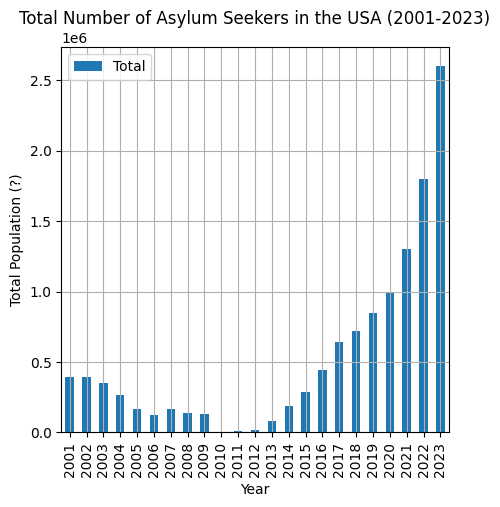

In [ ]:
# Plot Population Pivot Table
USA_population_pivot.plot(kind='bar')
# Add Title
plt.title('Total Number of Asylum Seekers in the USA (2001-2023)')
# Add Labels
plt.xlabel('Year')
plt.ylabel('Total Population (?)')
# Add Grid
plt.grid()

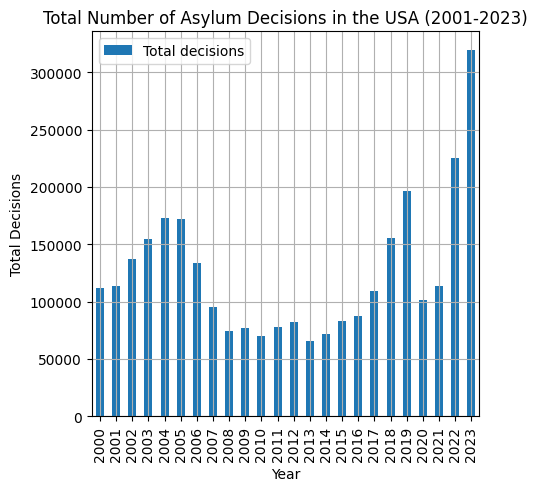

In [ ]:
# Plot Decisions Pivot Table
USA_decisions_pivot.plot(kind='bar')
# Add Title
plt.title('Total Number of Asylum Decisions in the USA (2001-2023)')
# Add Labels
plt.xlabel('Year')
plt.ylabel('Total Decisions')
# Add Grid
plt.grid()

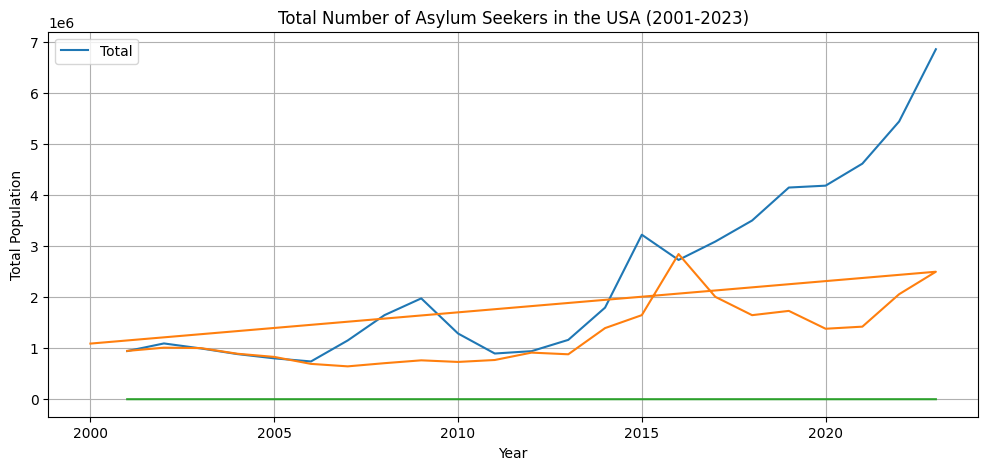

In [ ]:
USA_pivot.plot(kind='line', figsize=(12, 5))
# Add Title
plt.title('Total Number of Asylum Seekers in the USA (2001-2023)')
# Add Labels
plt.xlabel('Year')
plt.ylabel('Total Population')
# Add Legend
plt.legend(['Total'])
# Add Grid
plt.grid()

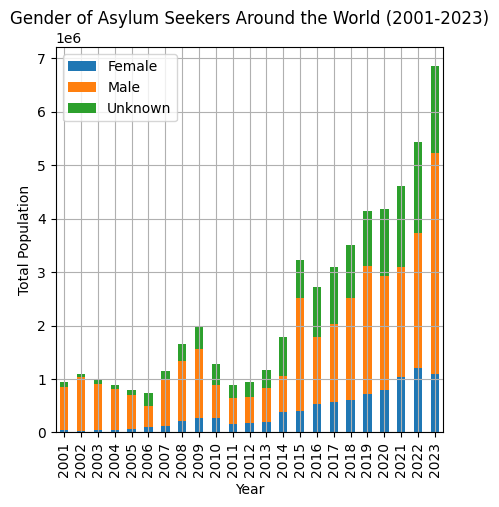

In [ ]:
# Create a Pivot Table to sum gender categories total over time
gender_pivot = population_df.pivot_table(index='Year', values=['Female total', 'Male total', 'Gender unknown'], aggfunc='sum')
# Plot Pivot Table
gender_pivot.plot(kind='bar', stacked=True)
# Add Title
plt.title('Gender of Asylum Seekers Around the World (2001-2023)')
# Add Labels
plt.xlabel('Year')
plt.ylabel('Total Population')
# Add Legend
plt.legend(['Female', 'Male', 'Unknown'])
# Add Grid
plt.grid()

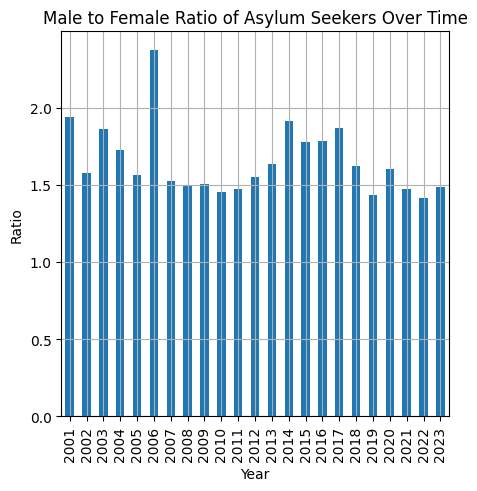

In [ ]:
# Create a "Male to Female Ratio"
gender_pivot['Male to Female Ratio'] = gender_pivot['Male total'] / gender_pivot['Female total']
# Plot Male to Female Ratio Over Time
gender_pivot['Male to Female Ratio'].plot(kind='bar')
# Add Title
plt.title('Male to Female Ratio of Asylum Seekers Over Time')
# Add Labels
plt.xlabel('Year')
plt.ylabel('Ratio')
# Add Grid
plt.grid()

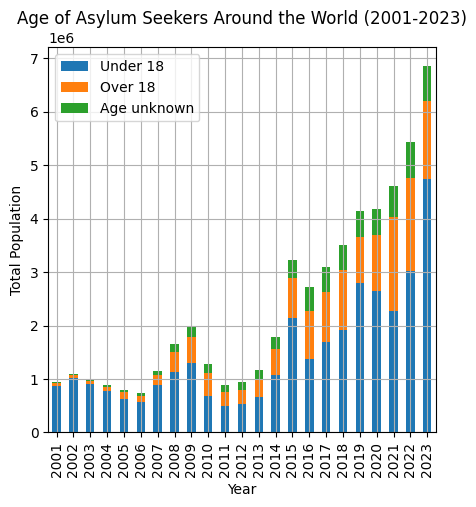

In [ ]:
# Create a Pivot Table to sum age categories over time
age_pivot = population_df.pivot_table(index='Year', values=['Under 18', 'Over 18', 'Age unknown'], aggfunc='sum')
# Plot Pivot Table
age_pivot.plot(kind='bar', stacked=True)
# Add Title
plt.title('Age of Asylum Seekers Around the World (2001-2023)')
# Add Labels
plt.xlabel('Year')
plt.ylabel('Total Population')
# Add Legend
plt.legend(['Under 18', 'Over 18', 'Age unknown'])
# Add Grid
plt.grid()

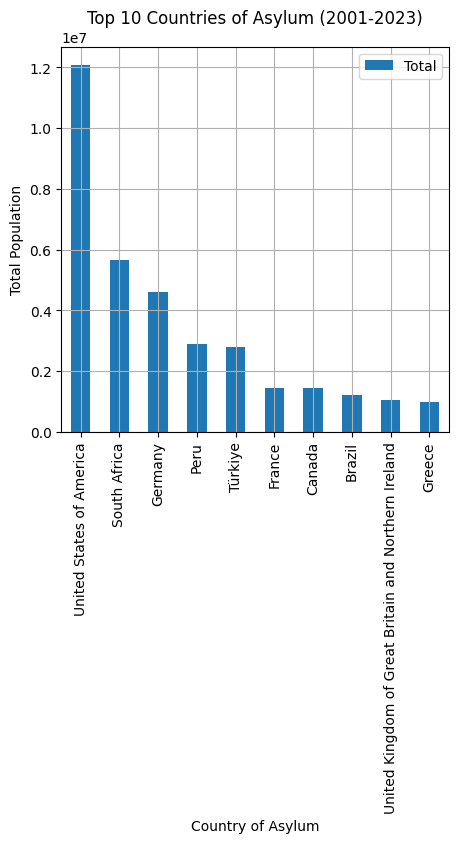

In [ ]:
# Create a Pivot Table to sum total per country of asylum
population_df.pivot_table(index='Country of asylum', values='Total', aggfunc='sum')
# Plot Top 10 Countries
population_df.pivot_table(index='Country of asylum', values='Total', aggfunc='sum').nlargest(10, 'Total').plot(kind='bar')
# Add Title
plt.title('Top 10 Countries of Asylum (2001-2023)')
# Add Labels
plt.xlabel('Country of Asylum')
plt.ylabel('Total Population')
# Add Grid
plt.grid()

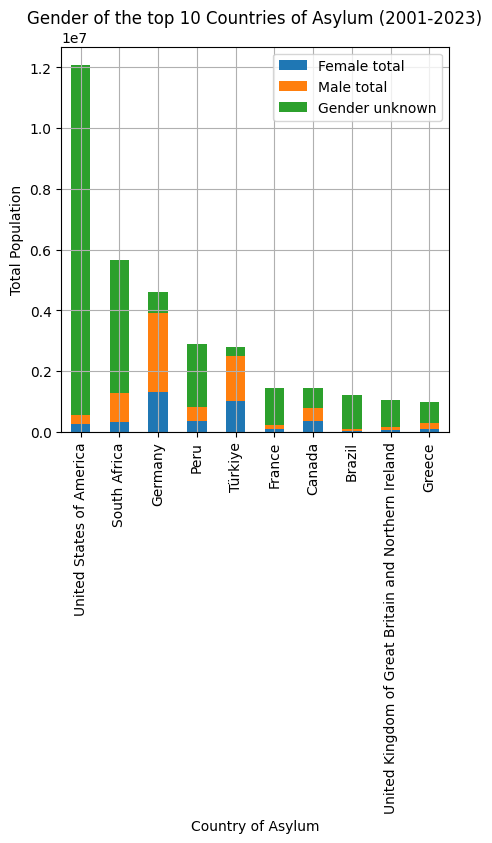

In [ ]:
# Create a Pivot Table to sum gender categories per country of asylum
pivot_df = population_df.pivot_table(index='Country of asylum', values=['Female total', 'Male total', 'Gender unknown'], aggfunc='sum')
# Calculate the total population for each country
pivot_df['Total'] = pivot_df['Female total'] + pivot_df['Male total'] + pivot_df['Gender unknown']
# Plot Top 10 Countries
top_10_countries = pivot_df.nlargest(10, 'Total')
top_10_countries[['Female total', 'Male total', 'Gender unknown']].plot(kind='bar', stacked=True)
# Add Title
plt.title('Gender of the top 10 Countries of Asylum (2001-2023)')
# Add Labels
plt.xlabel('Country of Asylum')
plt.ylabel('Total Population')
# Add Grid
plt.grid()

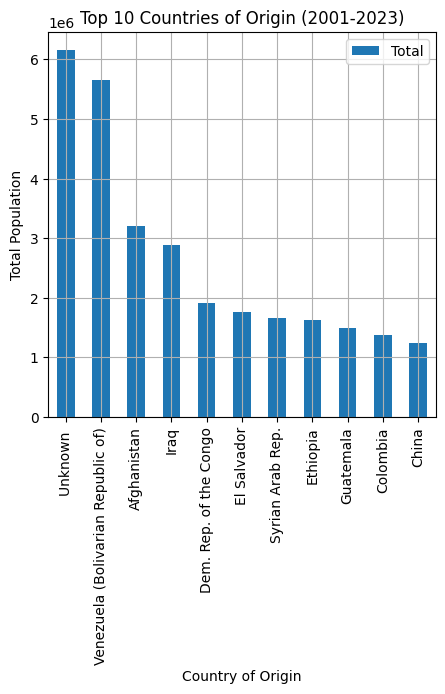

In [ ]:
# Create a Pivot Table to sum total per country of origin
population_df.pivot_table(index='Country of origin', values='Total', aggfunc='sum')
# Plot Top 10 Countries
population_df.pivot_table(index='Country of origin', values='Total', aggfunc='sum').nlargest(11, 'Total').plot(kind='bar')
# Add Title
plt.title('Top 10 Countries of Origin (2001-2023)')
# Add Labels
plt.xlabel('Country of Origin')
plt.ylabel('Total Population')
# Add Grid
plt.grid()

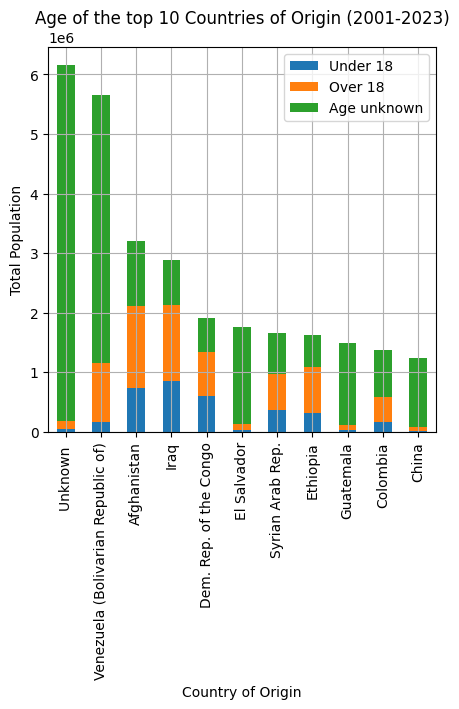

In [ ]:
# Create a Pivot Table to sum age categories per country of origin
pivot_df = population_df.pivot_table(index='Country of origin', values=['Under 18', 'Over 18', 'Age unknown'], aggfunc='sum')
# Calculate the total population for each country
pivot_df['Total'] = pivot_df['Under 18'] + pivot_df['Over 18'] + pivot_df['Age unknown']
# Plot Top 10 Countries
top_10_countries = pivot_df.nlargest(11, 'Total')
top_10_countries[['Under 18', 'Over 18', 'Age unknown']].plot(kind='bar', stacked=True)
# Add Title
plt.title('Age of the top 10 Countries of Origin (2001-2023)')
# Add Labels
plt.xlabel('Country of Origin')
plt.ylabel('Total Population')
# Add Grid
plt.grid()

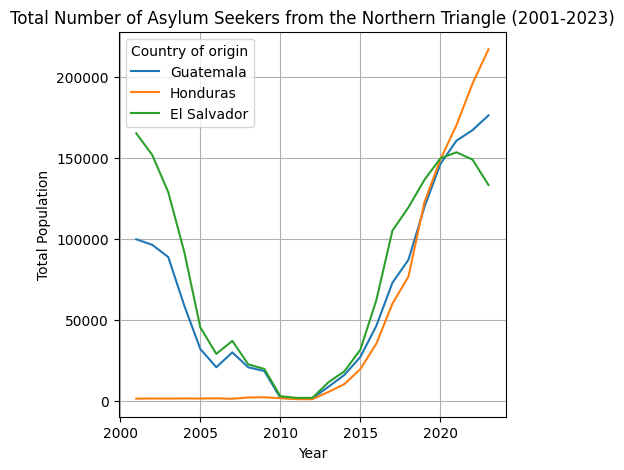

In [ ]:
# Line Graph: Northern Triangle over time
origin_time = population_df.pivot_table(index='Year', columns='Country of origin', values='Total', aggfunc='sum')
northern_triangle = origin_time[['Guatemala', 'Honduras', 'El Salvador']]
northern_triangle.plot(kind='line')
# Add Title
plt.title('Total Number of Asylum Seekers from the Northern Triangle (2001-2023)')
# Add Labels
plt.xlabel('Year')
plt.ylabel('Total Population')
# Add Grid
plt.grid()

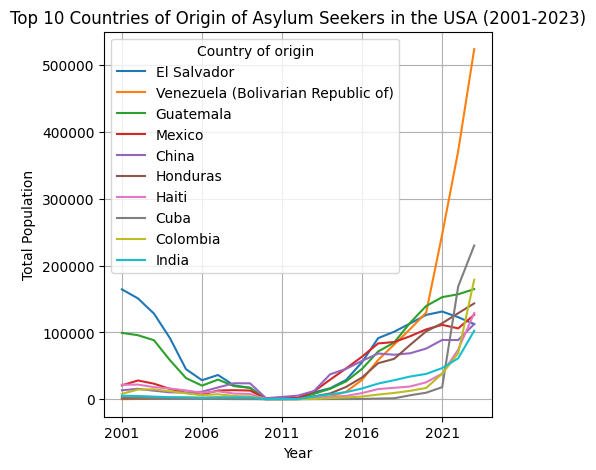

In [ ]:
# Filter United States
UnitedStates = population_df[population_df['Country of asylum'] == 'United States of America']
# Summarize country of origin vs year
US_pivot = UnitedStates.pivot_table(index='Country of origin', columns='Year', values='Total', aggfunc='sum')
# Add Total
US_pivot['Total'] = US_pivot.sum(axis=1)
# Get Top 10 Countries of origin
top_10_countries = US_pivot.nlargest(10, 'Total')
# Eliminate Total
top_10_countries = top_10_countries.drop('Total', axis=1)
# Plot Transposed
top_10_countries.T.plot(kind='line') # T (Transpose)
# Add Title
plt.title('Top 10 Countries of Origin of Asylum Seekers in the USA (2001-2023)')
# Add Labels
plt.xlabel('Year')
plt.ylabel('Total Population')
# Add Grid
plt.grid()

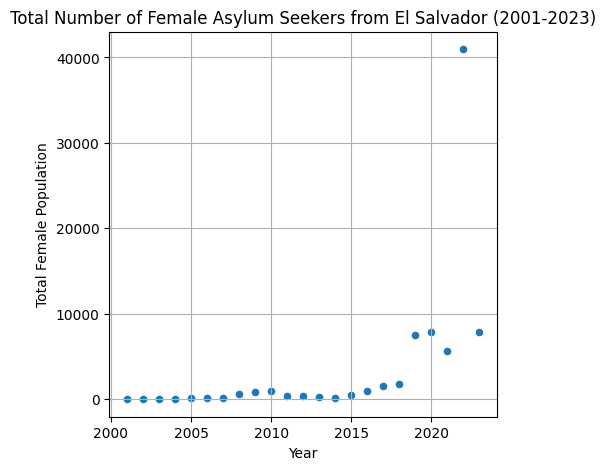

In [ ]:
# Filter data for El Salvador
df_el_salvador = population_df[population_df['Country of origin'] == 'El Salvador']
# Get Total Females over time
pivot_el_salvador = df_el_salvador.pivot_table(index='Year', values='Female total', aggfunc='sum')
pivot_el_salvador = pivot_el_salvador.reset_index()
# Scatter Plot
pivot_el_salvador.plot(kind='scatter', x='Year', y='Female total')
# Add Title
plt.title('Total Number of Female Asylum Seekers from El Salvador (2001-2023)')
# Add Labels
plt.xlabel('Year')
plt.ylabel('Total Female Population')
# Add Grid
plt.grid()

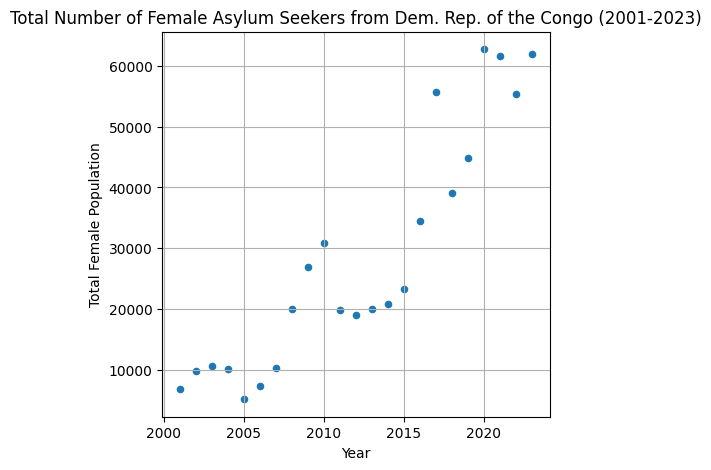

In [ ]:
# Filter data for Dem. Rep. of the Congo
df_congo = population_df[population_df['Country of origin'] == 'Dem. Rep. of the Congo']
# Get Total Females over time
pivot_congo = df_congo.pivot_table(index='Year', values='Female total', aggfunc='sum')
pivot_congo = pivot_congo.reset_index()
# Scatter Plot
pivot_congo.plot(kind='scatter', x='Year', y='Female total')
# Add Title
plt.title('Total Number of Female Asylum Seekers from Dem. Rep. of the Congo (2001-2023)')
# Add Labels
plt.xlabel('Year')
plt.ylabel('Total Female Population')
# Add Grid
plt.grid()

Text(0, 0.5, '')

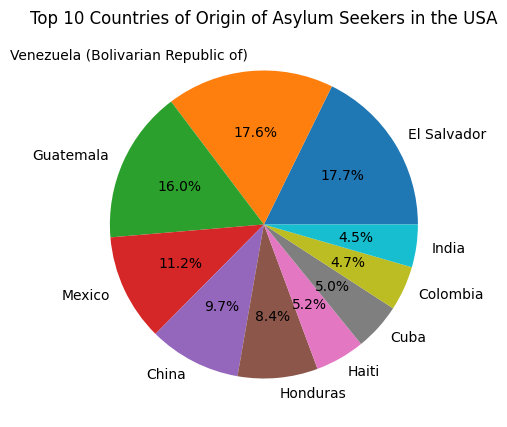

In [ ]:
# Filter United States
UnitedStates = population_df[population_df['Country of asylum'] == 'United States of America']
# Aggregate the total number of asylum seekers from each country of origin
top_countries = UnitedStates.groupby('Country of origin')['Total'].sum().nlargest(10)
# Plot the pie chart
top_countries.plot(kind='pie', autopct='%1.1f%%')
plt.title('Top 10 Countries of Origin of Asylum Seekers in the USA')
plt.ylabel('')  # Hides the y-label for better presentation

Text(0, 0.5, '')

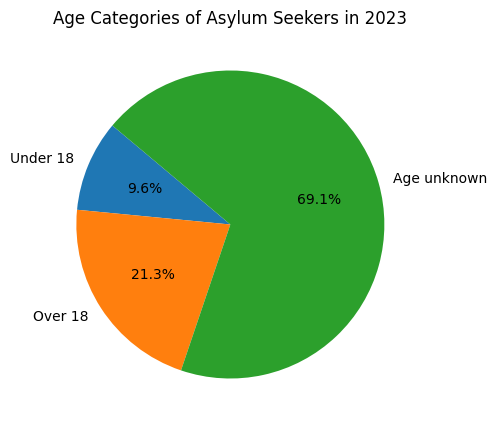

In [ ]:
# Pie Chart: Age Categories of Asylum Seekers in 2023
# Filter 2023
df_2023 = population_df[population_df['Year'] == 2023]
# Calculate the total for each age category
age_categories = {
    'Under 18': df_2023['Under 18'].sum(), 'Over 18': df_2023['Over 18'].sum(), 'Age unknown': df_2023['Age unknown'].sum()
    }
# Plot pie chart
plt.pie(age_categories.values(), labels=age_categories.keys(), autopct='%1.1f%%', startangle=140)
plt.title('Age Categories of Asylum Seekers in 2023')
plt.ylabel('')  # Hides the y-label for better presentation

Text(0, 0.5, '')

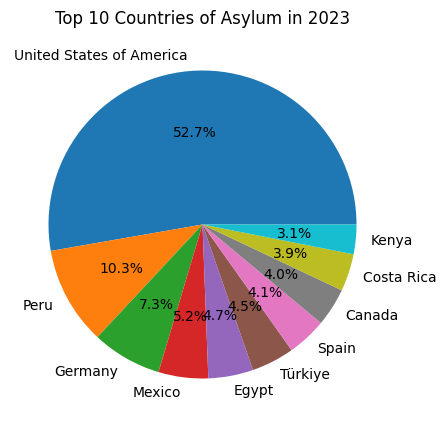

In [ ]:
# Filter 2023
df_2023 = population_df[population_df['Year'] == 2023]
# Aggregate the total number of asylum seekers from each country of origin
top_countries = df_2023.groupby('Country of asylum')['Total'].sum().nlargest(10)
# Plot the pie chart
top_countries.plot(kind='pie', autopct='%1.1f%%')
plt.title('Top 10 Countries of Asylum in 2023')
plt.ylabel('')  # Hides the y-label for better presentation

**B) The Decisions Data Set**:

**a. Introduction**:

In [ ]:
# Number of Rows
len(decisions_df)

103034

In [ ]:
# Number of columns
len(decisions_df.columns)

13

In [ ]:
# Number of data points
decisions_df.size

1339442

In [ ]:
# Show first 5 rows
decisions_df.head()

,Year,Country of origin,Country of origin (ISO),Country of asylum,Country of asylum (ISO),Authority,Stage of procedure,Cases / Persons,Recognized decisions,Complementary protection,Rejected decisions,Otherwise closed,Total decisions
0,2000,Afghanistan,AFG,Australia,AUS,G,AR,C,38,0,25,0,63
1,2000,Albania,ALB,Australia,AUS,G,AR,C,5,0,24,0,29
2,2000,Algeria,DZA,Australia,AUS,G,AR,C,5,0,17,0,22
3,2000,Egypt,EGY,Australia,AUS,G,AR,C,21,0,50,5,76
4,2000,Armenia,ARM,Australia,AUS,G,AR,C,0,0,5,0,5


In [ ]:
# Show last 5 rows
decisions_df.tail()

,Year,Country of origin,Country of origin (ISO),Country of asylum,Country of asylum (ISO),Authority,Stage of procedure,Cases / Persons,Recognized decisions,Complementary protection,Rejected decisions,Otherwise closed,Total decisions
103029,2023,Sudan,SDN,Jordan,JOR,U,RA,P,0,0,0,5,5
103030,2023,Afghanistan,AFG,Syrian Arab Rep.,SYR,U,RA,P,18,0,0,0,18
103031,2023,Yemen,YEM,Syrian Arab Rep.,SYR,U,RA,P,5,0,0,0,5
103032,2023,Pakistan,PAK,Thailand,THA,U,RA,P,0,0,0,17,17
103033,2023,Viet Nam,VNM,Thailand,THA,U,RA,P,0,0,13,24,37


**b. Data Types**:

In [ ]:
# Summary of DataFrame’s structure and information
decisions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103034 entries, 0 to 103033
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   Year                      103034 non-null  int64 
 1   Country of origin         103034 non-null  object
 2   Country of origin (ISO)   103034 non-null  object
 3   Country of asylum         103034 non-null  object
 4   Country of asylum (ISO)   103034 non-null  object
 5   Authority                 103034 non-null  object
 6   Stage of procedure        100897 non-null  object
 7   Cases / Persons           103034 non-null  object
 8   Recognized decisions      103034 non-null  int64 
 9   Complementary protection  103034 non-null  int64 
 10  Rejected decisions        103034 non-null  int64 
 11  Otherwise closed          103034 non-null  int64 
 12  Total decisions           103034 non-null  int64 
dtypes: int64(6), object(7)
memory usage: 10.2+ MB


**c. Descriptive Statistics**:

In [ ]:
# Generate descriptive statistics. Round to 2 decimal places.
decisions_df.describe().round(2)

,Year,Recognized decisions,Complementary protection,Rejected decisions,Otherwise closed,Total decisions
count,103034.00,103034.00,103034.00,103034.00,103034.00,103034.00
mean,2012.61,66.57,27.88,110.78,90.60,295.99
std,6.84,953.36,1097.08,811.18,2046.83,2941.42
min,2000.00,0.00,0.00,0.00,0.00,0.00
25%,2007.00,0.00,0.00,0.00,0.00,5.00
50%,2013.00,0.00,0.00,5.00,5.00,19.00
75%,2018.00,10.00,0.00,33.00,16.00,92.00
max,2023.00,164926.00,248201.00,147063.00,543233.00,543233.00


**d. Visualizations**:

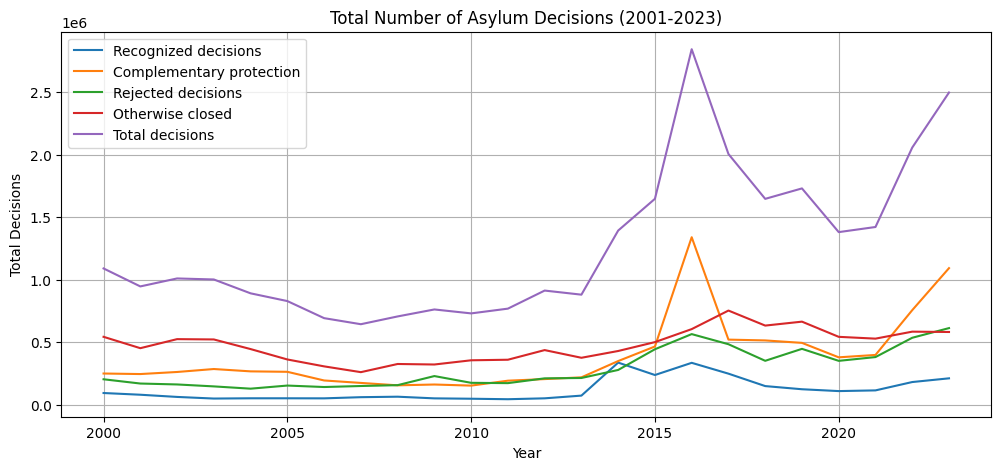

In [ ]:
# Create a Pivot Table to sum decision categories total over time
decisions_pivot = decisions_df.pivot_table(index='Year', values=["Recognized decisions",	"Complementary protection",	"Rejected decisions",	"Otherwise closed", "Total decisions"], aggfunc='sum')
# Plot Pivot Table
decisions_pivot.plot(kind='line', figsize=(12, 5))
# Add Title
plt.title('Total Number of Asylum Decisions (2001-2023)')
# Add Labels
plt.xlabel('Year')
plt.ylabel('Total Decisions')
# Add Legend
plt.legend(["Recognized decisions",	"Complementary protection",	"Rejected decisions",	"Otherwise closed", "Total decisions"])
# Add Grid
plt.grid()

Text(0, 0.5, 'Total Decisions')

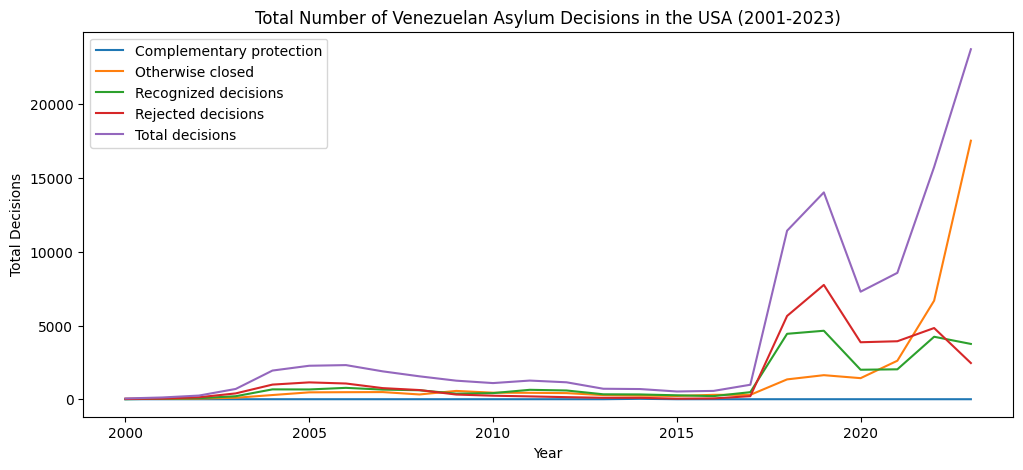

In [ ]:
# Filter United States
UnitedStates = decisions_df[decisions_df['Country of asylum'] == 'United States of America']
# Filter Venezuela as country of origin
Venezuela = UnitedStates[UnitedStates['Country of origin'] == 'Venezuela (Bolivarian Republic of)']
# Create a Pivot Table to sum decision categories total over time
decisions_pivot = Venezuela.pivot_table(index='Year', values=["Recognized decisions",	"Complementary protection",	"Rejected decisions",	"Otherwise closed", "Total decisions"], aggfunc='sum')
# Plot Pivot Table
decisions_pivot.plot(kind='line', figsize=(12, 5))
# Add Title
plt.title('Total Number of Venezuelan Asylum Decisions in the USA (2001-2023)')
# Add Labels
plt.xlabel('Year')
plt.ylabel('Total Decisions')

Text(0, 0.5, '')

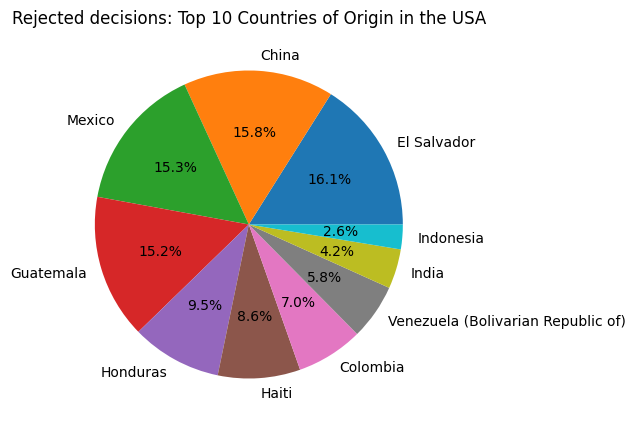

In [ ]:
# Filter United States
UnitedStates = decisions_df[decisions_df['Country of asylum'] == 'United States of America']
# Aggregate the total number of asylum seekers from each country of origin
top_countries = UnitedStates.groupby('Country of origin')['Rejected decisions'].sum().nlargest(10)
# Plot the pie chart
top_countries.plot(kind='pie', autopct='%1.1f%%')
plt.title('Rejected decisions: Top 10 Countries of Origin in the USA')
plt.ylabel('')  # Hides the y-label for better presentation

Text(0, 0.5, '')

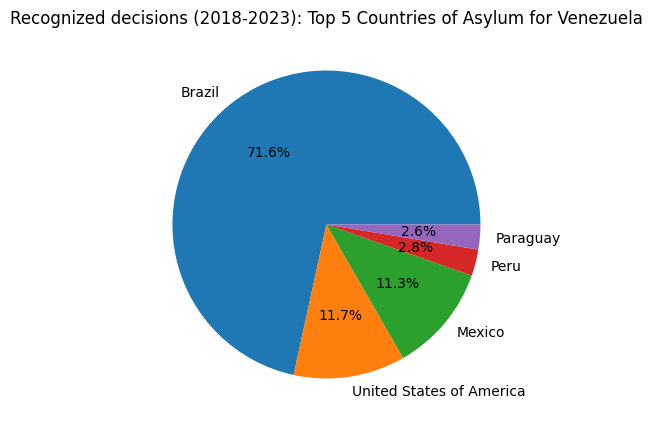

In [ ]:
# Filter Venezuela as country of origin
Venezuela = decisions_df[decisions_df['Country of origin'] == 'Venezuela (Bolivarian Republic of)']
# Filter 2018-2023
Venezuela_2018_2023 = Venezuela[(Venezuela['Year'] >= 2018) & (Venezuela['Year'] <= 2023)]
# Aggregate the total number of asylum seekers from each country of asylum
top_countries = Venezuela_2018_2023.groupby('Country of asylum')['Recognized decisions'].sum().nlargest(5)
# Plot the pie chart
top_countries.plot(kind='pie', autopct='%1.1f%%')
plt.title('Recognized decisions (2018-2023): Top 5 Countries of Asylum for Venezuela')
plt.ylabel('')  # Hides the y-label for better presentation

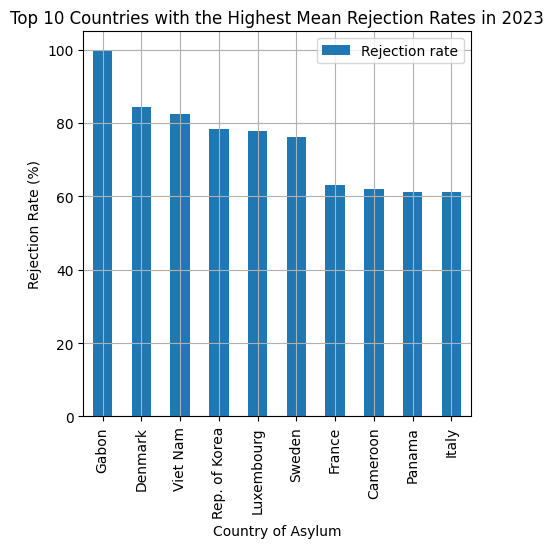

In [ ]:
# Create a rate of rejection
decisions_df['Rejection rate'] = 100 * decisions_df['Rejected decisions'] / decisions_df['Total decisions']
# Filter 2023
decisions_2023 = decisions_df[decisions_df['Year'] == 2023]
# Rejection rates mean
pivot_2023 = decisions_2023.pivot_table(index='Country of asylum', values='Rejection rate', aggfunc='mean')
# Bar Chart: Top 10 Countries with the highests mean rates of rejection in 2023
pivot_2023.sort_values(by='Rejection rate', ascending=False).head(10).plot(kind='bar')
# Add Title
plt.title('Top 10 Countries with the Highest Mean Rejection Rates in 2023')
# Add Labels
plt.xlabel('Country of Asylum')
plt.ylabel('Rejection Rate (%)')
# Add Grid
plt.grid()

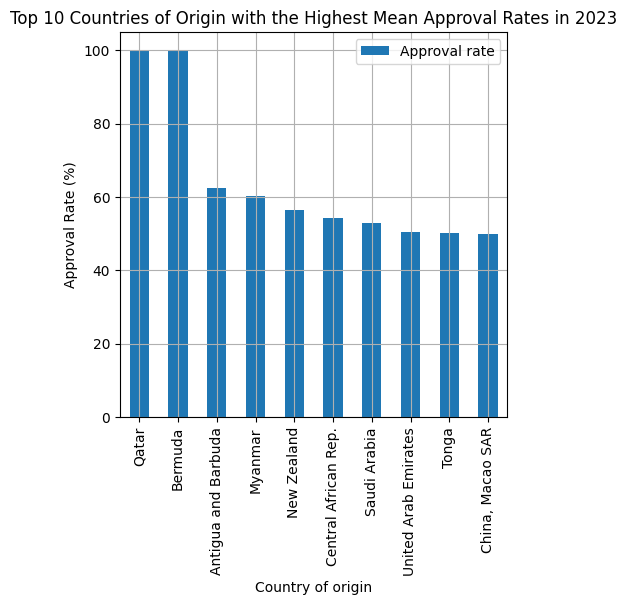

In [ ]:
# Create an Approval Rate
decisions_df['Approval rate'] = 100 * decisions_df['Recognized decisions'] / decisions_df['Total decisions']
# Filter 2023
decisions_2023 = decisions_df[decisions_df['Year'] == 2023]
# Approval rates mean
pivot_2023 = decisions_2023.pivot_table(index='Country of origin', values='Approval rate', aggfunc='mean')
# Bar Chart: Top 10 Countries with the highests mean rates of Approval in 2023
pivot_2023.sort_values(by='Approval rate', ascending=False).head(10).plot(kind='bar')
# Add Title
plt.title('Top 10 Countries of Origin with the Highest Mean Approval Rates in 2023')
# Add Labels
plt.xlabel('Country of origin')
plt.ylabel('Approval Rate (%)')
# Add Grid
plt.grid()

Text(0, 0.5, 'Otherwise closed')

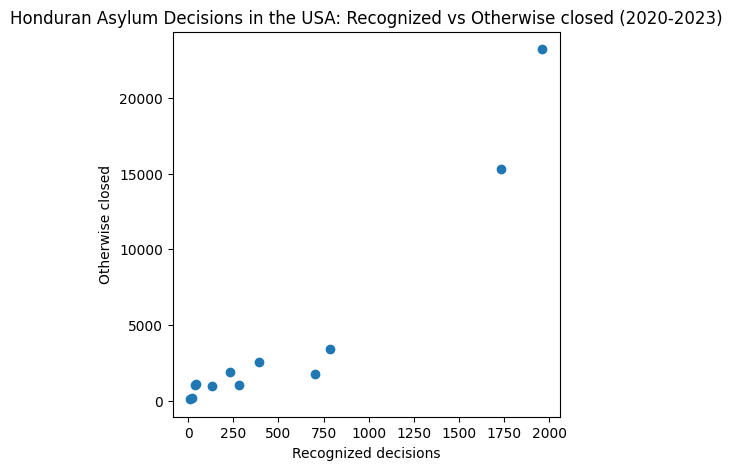

In [ ]:
# Filter USA
UnitedStates = decisions_df[decisions_df['Country of asylum'] == 'United States of America']
# Filter 2020-2023
UnitedStates_2020_2023 = UnitedStates[(UnitedStates['Year'] >= 2020) & (UnitedStates['Year'] <= 2023)]
# Filter Honduras as Country of origin
Honduras = UnitedStates_2020_2023[UnitedStates_2020_2023['Country of origin'] == 'Honduras']
# Scatter Plot: Recognized decisions	vs	Otherwise closed
plt.scatter(Honduras['Recognized decisions'], Honduras['Otherwise closed'])
# Add Title
plt.title('Honduran Asylum Decisions in the USA: Recognized vs Otherwise closed (2020-2023)')
# Add Labels
plt.xlabel('Recognized decisions')
plt.ylabel('Otherwise closed')
# Add Grid

Text(0, 0.5, 'Total decisions')

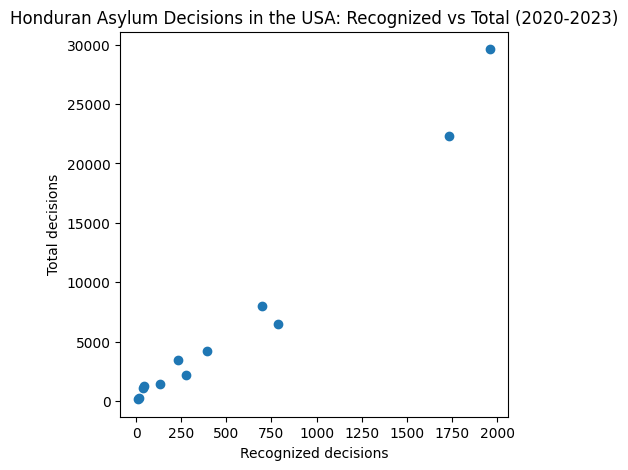

In [ ]:
# Scatter Plot: Recognized decisions	vs	Total decisions
plt.scatter(Honduras['Recognized decisions'], Honduras['Total decisions'])
# Add Title
plt.title('Honduran Asylum Decisions in the USA: Recognized vs Total (2020-2023)')
# Add Labels
plt.xlabel('Recognized decisions')
plt.ylabel('Total decisions')
# Add Grid

**Citations**:

About the United Nations High Commissioner for Refugees (UNHCR). UNHCR. (n.d.). https://www.unhcr.org/about-unhcr

Refugee Data Finder. UNHCR. (n.d.-b). https://www.unhcr.org/refugee-statistics/

In [ ]:
%%shell
jupyter nbconvert --to html Project_Checkpoint_I.ipynb

[NbConvertApp] WARNING | pattern 'Project_Checkpoint_I.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--ex

CalledProcessError: Command 'jupyter nbconvert --to html Project_Checkpoint_I.ipynb
' returned non-zero exit status 255.